In [ ]:
from google.colab import drive
drive .mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [ ]:
dataset1 = pd.read_csv('/content/drive/MyDrive/DL/DS ex1.csv')
X = dataset1[['INPUT']].values
y = dataset1[['OUTPUT']].values
print(X)
print(y)

[[15]
 [20]
 [32]
 [14]
 [15]
 [21]
 [16]
 [19]
 [22]
 [23]
 [28]
 [34]
 [12]
 [13]
 [28]
 [29]]
[[10]
 [12]
 [14]
 [20]
 [17]
 [10]
 [ 8]
 [15]
 [25]
 [21]
 [19]
 [23]
 [24]
 [27]
 [28]
 [30]]


In [ ]:
dataset1.head()

,INPUT,OUTPUT
0,15,10
1,20,12
2,32,14
3,14,20
4,15,17


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [ ]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [ ]:
# Name: ISWARYA P
# Register Number: 212223230082
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(1, 8)
        self.fc2=nn.Linear(8, 10)
        self.fc3=nn.Linear(10, 1)
        self.relu=nn.ReLU()
        self.history={'loss':[]}
  def forward(self, x):
        x=self.relu(self.fc1(x))
        x=self.relu(self.fc2(x))
        x=self.fc3(x)
        return x


In [ ]:
# Initialize the Model, Loss Function, and Optimizer
lig=NeuralNet()
criterion=nn.MSELoss()
optimizer=optim.RMSprop(lig. parameters(), lr=0.001);

In [ ]:
# Name: ISWARYA P
# Register Number: 212223230082
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    # Write your code here
    for epoch in range (epochs):
        optimizer. zero_grad()
        loss=criterion(ai_brain(X_train), y_train)
        loss. backward()
        optimizer.step()
        lig .history['loss'].append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')


In [ ]:
train_model(lig, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 328.572205
Epoch [200/2000], Loss: 112.523239
Epoch [400/2000], Loss: 44.378105
Epoch [600/2000], Loss: 35.182961
Epoch [800/2000], Loss: 29.766382
Epoch [1000/2000], Loss: 28.131613
Epoch [1200/2000], Loss: 28.061447
Epoch [1400/2000], Loss: 28.061451
Epoch [1600/2000], Loss: 28.061823
Epoch [1800/2000], Loss: 28.062809


In [ ]:
with torch.no_grad():
    test_loss = criterion(lig(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 88.715508


In [ ]:
loss_df = pd.DataFrame(lig.history)

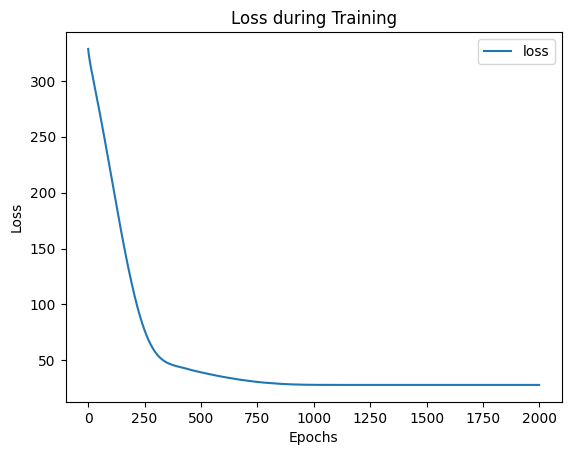

In [ ]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [ ]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = lig(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 17.971162796020508
